## __Phase 2: Data Preparation__

### __Import packages__

In [1]:
import pandas as pd
import numpy as np
from haversine import haversine
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
from scripts.data_pipeline.data_preprocessing.AIS.step01_filter_short_tracks import * 
from scripts.data_pipeline.data_preprocessing.AIS.step02_filter_speed_outliers import * 
from scripts.data_pipeline.data_preprocessing.AIS.step03_make_continuous_tracks import * 
from scripts.data_pipeline.data_preprocessing.AIS.step04_create_sample_data import * 

### __Load 'cargo' data__

In [3]:
df_preprocessing = (
    pd.read_parquet("../data/processed/cargo_vessels.parquet")[["MMSI", "IMO", "BaseDateTime", "LAT", "LON", "SOG", "Heading"]]
    .sort_values(["MMSI", "BaseDateTime"])
    .reset_index(drop=True)
    .copy()
)
df_preprocessing.head(5)

,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading
0,8,None,2024-01-31 16:57:25,47.55391,-122.65412,0.0,511.0
1,205717000,IMO9748485,2024-01-01 02:42:35,46.89866,-125.72790,13.2,92.0
2,205717000,IMO9748485,2024-01-01 03:09:33,46.89496,-125.59250,13.6,95.0
3,205717000,IMO9748485,2024-01-01 03:10:44,46.89473,-125.58606,13.6,95.0
4,205717000,IMO9748485,2024-01-01 03:20:54,46.89337,-125.52966,13.8,93.0


### __Step 1: Filter out trajectories that contain less than 5 data points__

In [4]:
df_prep_step1 = remove_short_tracks(df_preprocessing, min_observations=5)
df_prep_step1.head(5)

80 tracks with ≤ 5 observations were removed


,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading
1,205717000,IMO9748485,2024-01-01 02:42:35,46.89866,-125.72790,13.2,92.0
2,205717000,IMO9748485,2024-01-01 03:09:33,46.89496,-125.59250,13.6,95.0
3,205717000,IMO9748485,2024-01-01 03:10:44,46.89473,-125.58606,13.6,95.0
4,205717000,IMO9748485,2024-01-01 03:20:54,46.89337,-125.52966,13.8,93.0
5,205717000,IMO9748485,2024-01-01 03:23:14,46.89343,-125.51669,13.7,93.0


### __Step 2: Filtering unrealistic vessel speeds__

AIS data was filtered to exclude extreme and unlikely speeds. This includes removing vessels that were either nearly stationary or moving at technically implausible speeds.


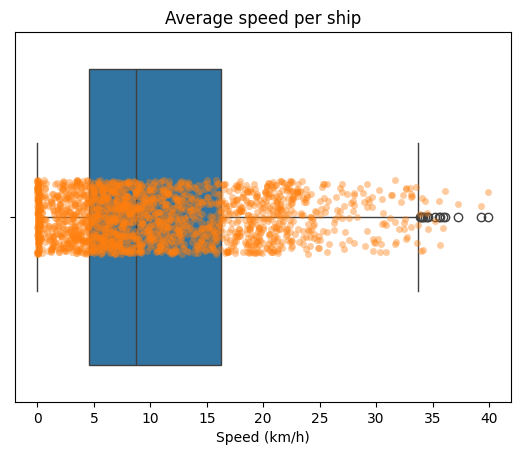

In [5]:
# Remove high-speed outliers (unrealistically fast vessels, as observed during data exploration (phase 1))
df_prep_step2 = df_prep_step1.copy()
df_speed = add_speed_info(df_prep_step2)

df_prep_step2 = remove_high_speed_outliers(df_speed)
avg_speeds_boxplot_1 = df_prep_step2.groupby("MMSI")["speed_kph"].mean().reset_index()

sns.boxplot(data=avg_speeds_boxplot_1, x="speed_kph")
sns.stripplot(data=avg_speeds_boxplot_1, x="speed_kph", alpha=0.4, jitter=True)
plt.title("Average speed per ship")
plt.xlabel("Speed (km/h)")
plt.show()

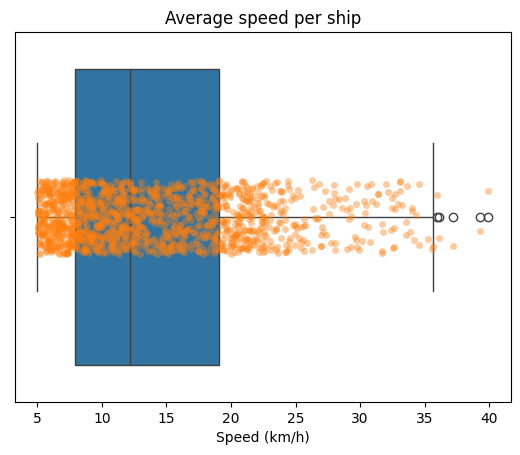

In [6]:
# Remove tracks with average speed below threshold (defaults is set to 5 km/h)
df_prep_step2 = remove_low_speed_outliers(df_prep_step2)
avg_speeds_boxplot_2 = df_prep_step2.groupby("MMSI")["speed_kph"].mean().reset_index()

sns.boxplot(data=avg_speeds_boxplot_2, x="speed_kph")
sns.stripplot(data=avg_speeds_boxplot_2, x="speed_kph", alpha=0.4, jitter=True)
plt.title("Average speed per ship")
plt.xlabel("Speed (km/h)")
plt.show()

### __Step 3: Handeling incomplete vessel tracks__

Some ships transmitted AIS signals only intermittently, leading to large time gaps between observations. A new trajectory (subroute) was initiated whenever the time gap exceeded the 99th percentile (~9 minutes)

In [7]:
df_prep_step3 = df_prep_step2.copy()
df_prep_step3 = split_into_continuous_tracks(df_prep_step3)
df_prep_step3.head(5)

,ID,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,time_diff,distance_diff,speed_kph,track_id
0,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:40:24,46.89339,-125.42151,13.7,93.0,NaN,NaN,NaN,3
1,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:44:15,46.89344,-125.39996,13.8,93.0,231.0,1.637508,25.519605,3
2,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:45:33,46.89350,-125.39274,13.9,94.0,78.0,0.548659,25.322724,3
3,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:46:39,46.89348,-125.38572,13.9,93.0,66.0,0.533426,29.095947,3
4,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:48:20,46.89355,-125.37695,13.9,93.0,101.0,0.666442,23.754352,3


In [ ]:
# je zou hier nog de route kunnen plotten voor het spliten en na het splitsen 

### __Step 4: Sampling a representative set of routes from the AIS population__

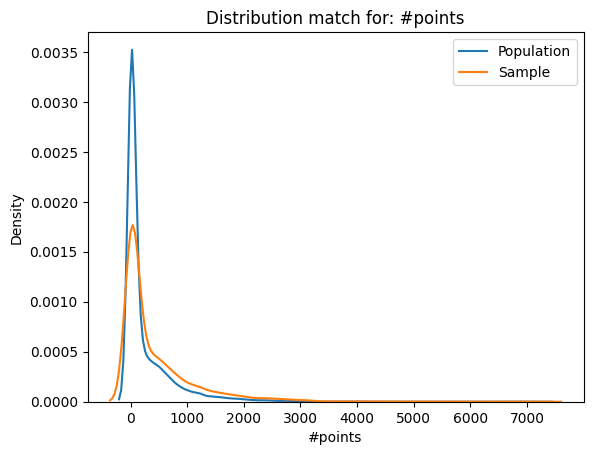

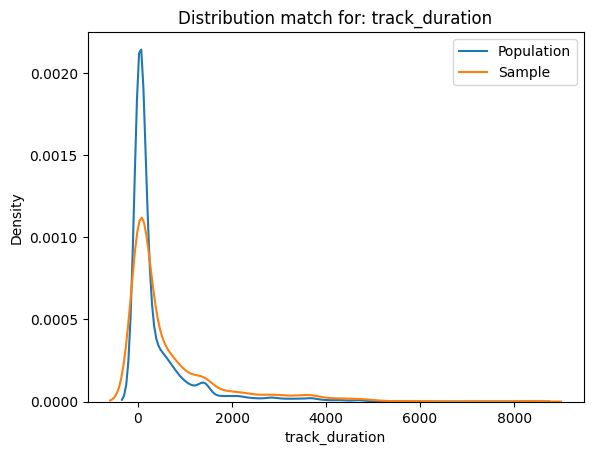

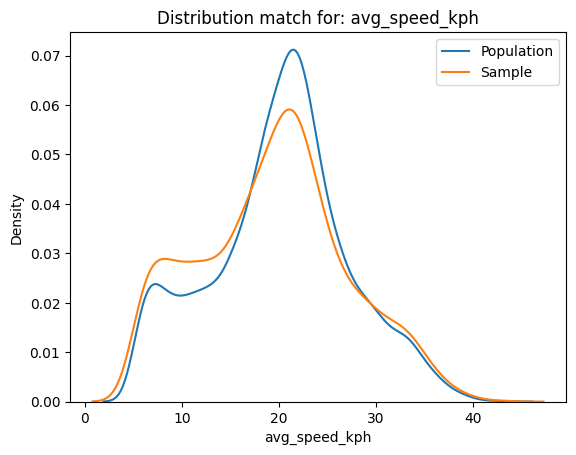

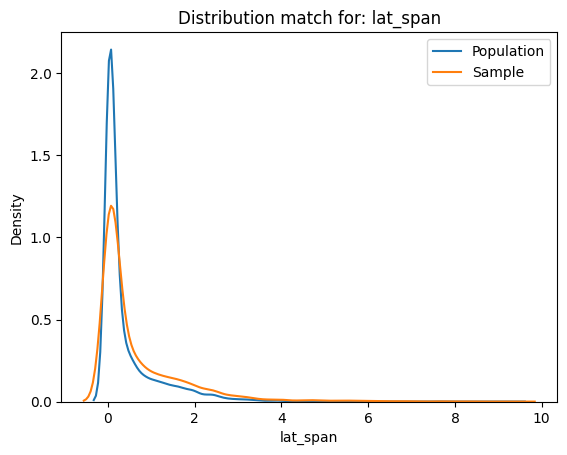

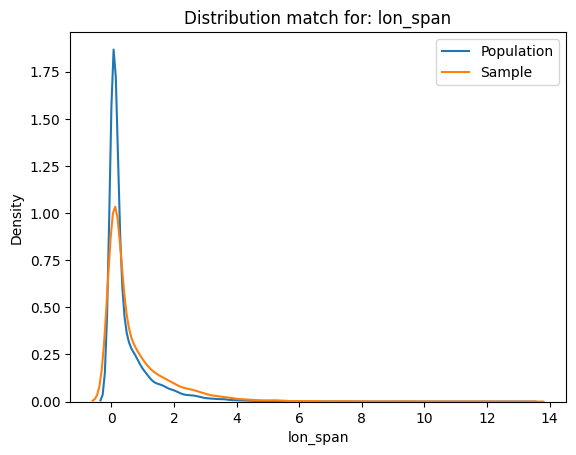

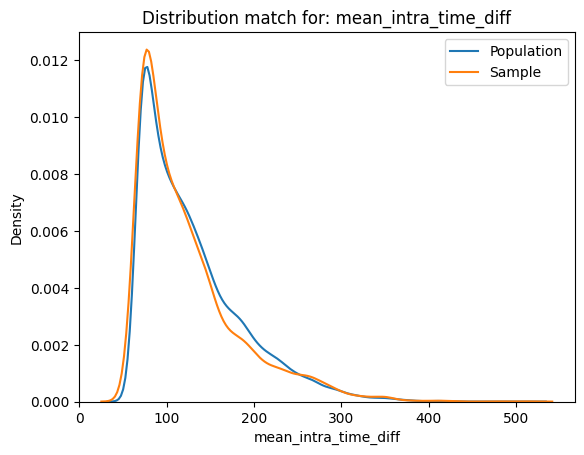

In [9]:
sampled_tracks, AIS_charateristics, columns, df_subset = sample_representative_routes(df_prep_step3)

for col in columns:
    sns.kdeplot(AIS_charateristics[col], label="Population")
    sns.kdeplot(sampled_tracks[col], label="Sample")
    plt.title(f"Distribution match for: {col}")
    plt.legend()
    plt.show()

In [ ]:
# hier komt het genereren van RF signals 

In [ ]:
# hier komt het genereren van 'echte' training data